#**Diagnosting Airlane Delay Patterns to Improve Customer Experience in Online Travel Platforms**

#Project Objective

This project aims to understand flight delay patterns and their impact on customer experience in online travel platforms. Specifically, the analysis focuses on identifying the main causes of delays, evaluating airline performance based on delays and cancellations, and uncovering patterns that can improve service quality. The insights generated are expected to help the platform optimize flight recommendations, enhance transparency, and ultimately improve customer trust and satisfaction

#BUSINESS CONTEXT

In the online travel industry, user experience plays a crucial role in customer retention. Flight delays and cancellations are common issues that negatively impact user satisfaction. If not properly addressed, these issues can lead to lower conversion rates and reduced customer loyalty. Therefore, data-driven analysis is essential to understand the root causes and provide actionable recommendations

#Import Libraries

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

At this stage, I import the main libraries for data processing, visualization, and SQL execution. This setup enables a complete end-to-end analysis within a single environment

#Data Loading

In [2]:
df = pd.read_csv('Airline_Delay_Cause.csv')

In [3]:
df.head()

,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2023,8,9E,Endeavor Air Inc.,ABE,"Allentown/Bethlehem/Easton, PA: Lehigh Valley ...",89.0,13.0,2.25,1.60,...,0.0,5.99,2.0,1.0,1375.0,71.0,761.0,118.0,0.0,425.0
1,2023,8,9E,Endeavor Air Inc.,ABY,"Albany, GA: Southwest Georgia Regional",62.0,10.0,1.97,0.04,...,0.0,7.42,0.0,1.0,799.0,218.0,1.0,62.0,0.0,518.0
2,2023,8,9E,Endeavor Air Inc.,AEX,"Alexandria, LA: Alexandria International",62.0,10.0,2.73,1.18,...,0.0,4.28,1.0,0.0,766.0,56.0,188.0,78.0,0.0,444.0
3,2023,8,9E,Endeavor Air Inc.,AGS,"Augusta, GA: Augusta Regional at Bush Field",66.0,12.0,3.69,2.27,...,0.0,1.57,1.0,1.0,1397.0,471.0,320.0,388.0,0.0,218.0
4,2023,8,9E,Endeavor Air Inc.,ALB,"Albany, NY: Albany International",92.0,22.0,7.76,0.00,...,0.0,11.28,2.0,0.0,1530.0,628.0,0.0,134.0,0.0,768.0


In this step, the dataset is loaded into the Google Colab environment using pandas. The first few rows are displayed to ensure the data has been successfully loaded

#Data Understanding

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 171666 entries, 0 to 171665
Data columns (total 21 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   year                 171666 non-null  int64  
 1   month                171666 non-null  int64  
 2   carrier              171666 non-null  object 
 3   carrier_name         171666 non-null  object 
 4   airport              171666 non-null  object 
 5   airport_name         171666 non-null  object 
 6   arr_flights          171426 non-null  float64
 7   arr_del15            171223 non-null  float64
 8   carrier_ct           171426 non-null  float64
 9   weather_ct           171426 non-null  float64
 10  nas_ct               171426 non-null  float64
 11  security_ct          171426 non-null  float64
 12  late_aircraft_ct     171426 non-null  float64
 13  arr_cancelled        171426 non-null  float64
 14  arr_diverted         171426 non-null  float64
 15  arr_delay        

In [5]:
df.describe()

,year,month,arr_flights,arr_del15,carrier_ct,weather_ct,nas_ct,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
count,171666.000000,171666.000000,171426.000000,171223.000000,171426.000000,171426.000000,171426.000000,171426.000000,171426.000000,171426.000000,171426.000000,171426.00000,171426.000000,171426.000000,171426.000000,171426.000000,171426.000000
mean,2018.551361,6.493633,362.528467,66.434387,20.796615,2.250347,19.381147,0.157096,23.770554,7.530497,0.863387,4239.48733,1437.185124,222.563497,920.651704,7.382725,1651.700063
std,2.890006,3.440908,992.894662,179.540694,50.315176,7.314252,61.675244,0.717405,72.393477,43.654880,3.772853,12618.56605,4215.677812,821.086511,3423.509335,41.779985,5221.878385
min,2013.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2016.000000,4.000000,50.000000,6.000000,2.160000,0.000000,1.000000,0.000000,1.230000,0.000000,0.000000,335.00000,110.000000,0.000000,34.000000,0.000000,65.000000
50%,2019.000000,7.000000,100.000000,17.000000,6.400000,0.400000,3.910000,0.000000,5.000000,1.000000,0.000000,1018.00000,375.000000,18.000000,146.000000,0.000000,320.000000
75%,2021.000000,9.000000,250.000000,47.000000,17.260000,1.860000,11.710000,0.000000,15.260000,4.000000,1.000000,2884.00000,1109.000000,146.000000,477.000000,0.000000,1070.000000
max,2023.000000,12.000000,21977.000000,4176.000000,1293.910000,266.420000,1884.420000,58.690000,2069.070000,4951.000000,197.000000,438783.00000,196944.000000,31960.000000,112018.000000,3760.000000,227959.000000


This step aims to understand the structure and characteristics of the dataset. The info() function provides insights into data types and completeness, while describe() summarizes statistical distributions such as mean, minimum, and maximum values

#Data Cleaning

In [6]:
df.shape

(171666, 21)

##Handling Missing Value

In [7]:
df.isnull().sum()

,0
year,0
month,0
carrier,0
carrier_name,0
airport,0
airport_name,0
arr_flights,240
arr_del15,443
carrier_ct,240
weather_ct,240


In [8]:
df[df['arr_delay'].isnull()].head()

,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
3880,2023,6,MQ,Envoy Air,CLL,"College Station/Bryan, TX: Easterwood Field",NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3894,2023,6,MQ,Envoy Air,EUG,"Eugene, OR: Mahlon Sweet Field",NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3898,2023,6,MQ,Envoy Air,FSD,"Sioux Falls, SD: Joe Foss Field",NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3904,2023,6,MQ,Envoy Air,GRB,"Green Bay, WI: Green Bay Austin Straubel Inter...",NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3910,2023,6,MQ,Envoy Air,HPN,"White Plains, NY: Westchester County",NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
df = df.dropna()

During the missing value exploration, it was observed that null values occur simultaneously across almost all numerical columns within certain rows. This indicates that the data for those rows is not available or not fully reported, rather than representing actual zero values.

Since the missing values affect entire rows, imputation methods such as replacing them with zero are not appropriate, as they may lead to incorrect interpretations—for example, assuming no delays when the data is actually unavailable. Therefore, rows with missing values are removed to preserve data quality and analytical validity

##Standaridze Coulumns

In [10]:
df.columns

Index(['year', 'month', 'carrier', 'carrier_name', 'airport', 'airport_name',
       'arr_flights', 'arr_del15', 'carrier_ct', 'weather_ct', 'nas_ct',
       'security_ct', 'late_aircraft_ct', 'arr_cancelled', 'arr_diverted',
       'arr_delay', 'carrier_delay', 'weather_delay', 'nas_delay',
       'security_delay', 'late_aircraft_delay'],
      dtype='object')

In [11]:
df = df.rename(columns={
    'arr_del15': 'arr_delay_15',
    'carrier_ct': 'carrier_count',
    'weather_ct': 'weather_count',
    'nas_ct': 'nas_count',
    'security_ct': 'security_count',
    'late_aircraft_ct': 'late_aircraft_count'})

In [12]:
df.columns

Index(['year', 'month', 'carrier', 'carrier_name', 'airport', 'airport_name',
       'arr_flights', 'arr_delay_15', 'carrier_count', 'weather_count',
       'nas_count', 'security_count', 'late_aircraft_count', 'arr_cancelled',
       'arr_diverted', 'arr_delay', 'carrier_delay', 'weather_delay',
       'nas_delay', 'security_delay', 'late_aircraft_delay'],
      dtype='object')

Column renaming is performed selectively to improve readability and consistency without altering the core structure of the dataset. Abbreviations such as “ct” are expanded to “count” to make them more intuitive, especially in a business context. Additionally, names like “arr_del15” are refined into “arr_delay_15” to provide clearer meaning.

This adjustment helps simplify the analysis process, reduce potential coding errors, and improve clarity when communicating insights to non-technical stakeholders

##Remove Duplicates

In [13]:
df.duplicated().sum()

np.int64(0)

At this stage, a duplicate check is performed to ensure that no records are counted more than once. The results indicate that there are no duplicate entries in the dataset, so no removal process is required. This suggests that the dataset already maintains a good level of data uniqueness

##Data Type Validation

In [14]:
df.dtypes

,0
year,int64
month,int64
carrier,object
carrier_name,object
airport,object
airport_name,object
arr_flights,float64
arr_delay_15,float64
carrier_count,float64
weather_count,float64


Based on the data type inspection, most numerical columns such as arr_flights, delay components (carrier_delay, weather_delay, nas_delay), and total delay (arr_delay) are correctly stored as float64, which is appropriate for quantitative analysis.

However, several important observations need to be addressed. Columns such as carrier, carrier_name, airport, and airport_name are still in object format, indicating categorical data. Additionally, columns like arr_cancelled and arr_diverted are stored as floats, even though they represent count-based metrics and should ideally be treated as discrete numerical values.

This indicates that while the dataset is generally well-structured, further refinement is necessary to improve analytical efficiency and ensure accurate interpretation

###Data Type Improvement

In [15]:
# Convert categorical columns
categorical_cols = ['carrier', 'carrier_name', 'airport', 'airport_name']

for col in categorical_cols:
    df[col] = df[col].astype('category')

In [16]:
# Convert count-based columns to integer
count_cols = [
    'arr_flights',
    'arr_cancelled',
    'arr_diverted'
]

for col in count_cols:
    df[col] = df[col].astype(int)

In [17]:
# Final check
df.dtypes

,0
year,int64
month,int64
carrier,category
carrier_name,category
airport,category
airport_name,category
arr_flights,int64
arr_delay_15,float64
carrier_count,float64
weather_count,float64


Following the evaluation, data type adjustments were made to improve analytical quality. Categorical columns such as airline and airport identifiers were converted to the category type to enhance memory efficiency and simplify aggregation.

Additionally, count-based fields such as arr_flights, arr_cancelled, and arr_diverted were converted to integer format since they represent discrete values. These adjustments ensure that the dataset is not only technically correct but also aligned with its business context

##Exploratory Data Analysis

###Delay by Clause

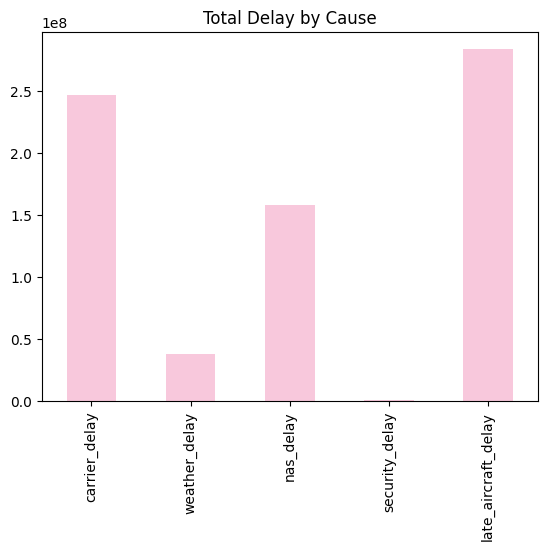

In [37]:
delay_causes = df[['carrier_delay','weather_delay','nas_delay','security_delay','late_aircraft_delay']].sum()

delay_causes.plot(kind='bar', color='#F8C8DC')
plt.title('Total Delay by Cause')
plt.savefig('total_delay.png')
plt.show()

The visualization above presents the total contribution of each delay type to overall flight delays. It shows that late aircraft delay is the most significant contributor, followed by carrier delay and NAS delay, while weather delay and security delay have relatively minor contributions.

This finding indicates that most delays are driven by internal operational factors, particularly delays caused by previous flights, which create a cascading effect on subsequent schedules. This suggests potential inefficiencies in aircraft rotation and scheduling management. On the other hand, the relatively low contribution of external factors such as weather and security implies that delays are not primarily caused by uncontrollable conditions, but rather by airline operations.

This insight is highly relevant for online travel platforms, as it can be used to assess airline service quality and incorporate on-time performance as a key factor in flight recommendation systems

###Airlane Perfomance Based On Average Delay

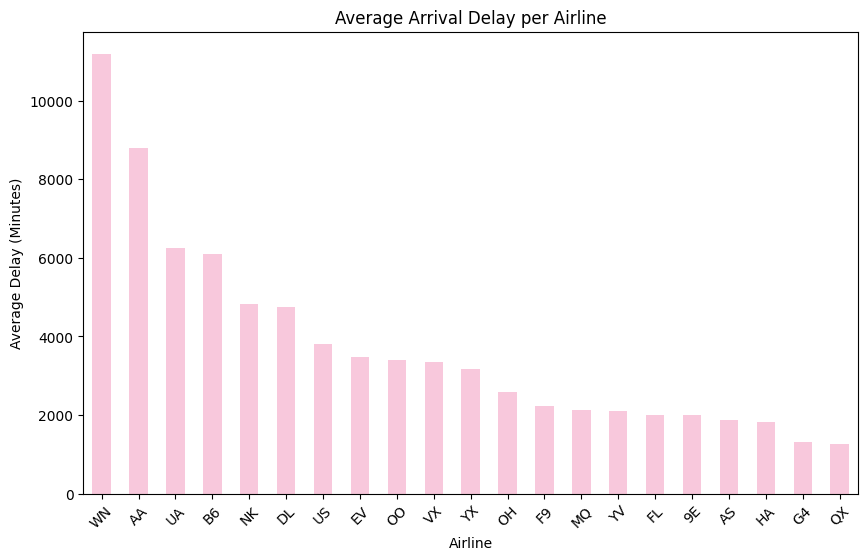

In [38]:
import warnings
warnings.filterwarnings('ignore')

# Calculate average delay per airline
airline_performance = df.groupby('carrier', observed=False)['arr_delay'].mean().sort_values(ascending=False)

# Plot
plt.figure(figsize=(10,6))
airline_performance.plot(kind='bar', color='#F8C8DC')

plt.title('Average Arrival Delay per Airline')
plt.xlabel('Airline')
plt.ylabel('Average Delay (Minutes)')
plt.xticks(rotation=45)
plt.savefig('average_arrival.png')

plt.show()

This analysis evaluates airline performance based on average arrival delay. By grouping the data by airline and calculating the mean delay, we can objectively compare how each carrier performs. The visualization makes it easier to identify airlines that consistently experience higher delays.

The results show that several airlines have significantly higher average delays than others. This pattern suggests potential inefficiencies in operations or scheduling management. This insight is crucial, as underperforming airlines can negatively impact customer satisfaction. Therefore, an online travel platform may consider prioritizing better-performing airlines in search results or providing delay-related information to help users make more informed decisions

##SQL Analysis

###Create SQL Environment

In [24]:
conn = sqlite3.connect(':memory:')
df.to_sql('airline', conn, index=False, if_exists='replace')

171223

In this step, the dataset is loaded into a temporary SQLite database to enable SQL-based analysis. This approach is chosen to simulate a real-world working environment, where data is typically stored and processed in relational databases. It allows the analysis to be more structured and aligned with industry practices

####Query 1 : High-Risk Airlines

In [45]:
query_1 = """
SELECT carrier,
       AVG(arr_delay) AS avg_delay,
       SUM(arr_cancelled) * 1.0 / COUNT(*) AS cancel_rate
FROM airline
GROUP BY carrier
ORDER BY avg_delay DESC, cancel_rate DESC;
"""

result_1 = pd.read_sql_query(query_1, conn)
result_1.head()

,carrier,avg_delay,cancel_rate
0,WN,11188.673778,24.842560
1,AA,8786.618935,14.180032
2,UA,6255.616145,7.723389
3,B6,6095.361866,7.882072
4,NK,4817.507358,7.256771


This analysis aims to identify high-risk airlines by combining average delay and cancellation rate. By evaluating these two metrics together, we gain a more complete view of airline reliability, as both delays and cancellations directly impact customer experience.

The results show that airlines such as WN have the highest average delay along with a relatively high cancellation rate, indicating a significant operational risk. Other airlines like AA and UA also demonstrate weaker performance compared to their peers. This suggests that airline reliability varies significantly, and certain carriers may negatively impact user experience. This insight is crucial for prioritizing airline visibility within the platform

####Query 2 : Root Cause per Airline

In [46]:
query_2 = """
SELECT carrier,
       SUM(carrier_delay) AS carrier_delay,
       SUM(weather_delay) AS weather_delay,
       SUM(nas_delay) AS nas_delay,
       SUM(late_aircraft_delay) AS late_aircraft_delay
FROM airline
GROUP BY carrier
ORDER BY late_aircraft_delay DESC;
"""

result_2 = pd.read_sql_query(query_2, conn)
result_2

,carrier,carrier_delay,weather_delay,nas_delay,late_aircraft_delay
0,WN,38863590.0,3808146.0,18850485.0,62491506.0
1,AA,36455506.0,5315301.0,20797721.0,40980232.0
2,OO,36089841.0,7506303.0,13011469.0,30351977.0
3,UA,20370722.0,3592359.0,18602248.0,27707777.0
4,DL,33233035.0,5260651.0,18286679.0,22176227.0
5,B6,16264717.0,1336605.0,10278881.0,18007416.0
6,EV,13659556.0,1024081.0,10280829.0,15019306.0
7,MQ,6892609.0,2720106.0,7235507.0,10549636.0
8,F9,5680841.0,402423.0,5101309.0,9167152.0
9,OH,4602302.0,1097121.0,2599405.0,7694371.0


This analysis aims to identify the root causes of delays for each airline by breaking them down into categories such as carrier delay, weather delay, NAS delay, and late aircraft delay. This approach helps determine whether delays are driven by internal operations or external factors.

The results indicate that most airlines, including WN, AA, and OO, are heavily dominated by late aircraft delays. This suggests that delays are largely caused by cascading operational issues from previous flights rather than external factors like weather. In other words, inefficiencies in scheduling and aircraft turnaround processes are likely the main contributors. This insight highlights a key opportunity for operational improvement

####Query 3 : Operational Issue Indicator

In [47]:
query_3 = """
SELECT
    SUM(late_aircraft_delay) * 1.0 / SUM(arr_delay) AS operational_ratio
FROM airline;
"""

result_3 = pd.read_sql_query(query_3, conn)
result_3.head()

,operational_ratio
0,0.389599


This analysis measures the proportion of delays caused by operational factors, specifically late aircraft delays, relative to total delays. This ratio helps determine whether the primary issue lies within internal operations or external conditions.

The result shows that approximately 38.6% of total delays are attributed to operational factors. This is a significant proportion, indicating that a large portion of delays is driven by internal inefficiencies rather than uncontrollable external factors. This insight suggests that improving operational management, such as scheduling optimization and aircraft turnaround efficiency, could substantially reduce overall delays

###Visualizing SQL Result

####High Risk Airlines- Query 1

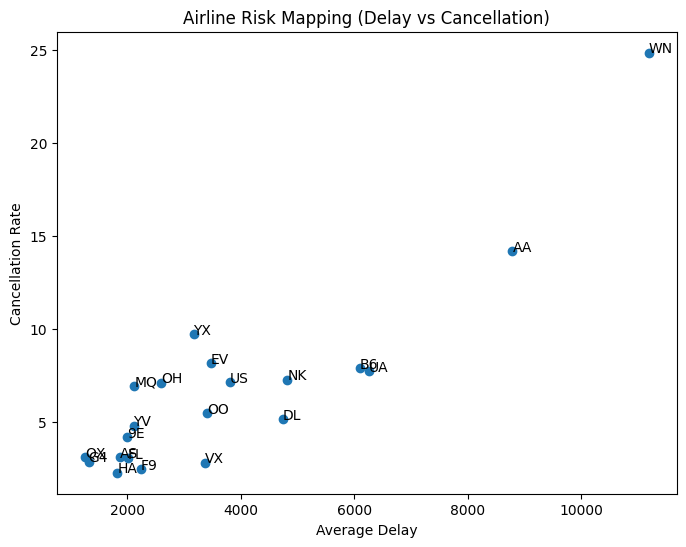

In [51]:
plt.figure(figsize=(8,6))
plt.scatter(result_1['avg_delay'], result_1['cancel_rate'])

for i, txt in enumerate(result_1['carrier']):
    plt.annotate(txt, (result_1['avg_delay'][i], result_1['cancel_rate'][i]))

plt.xlabel('Average Delay')
plt.ylabel('Cancellation Rate')
plt.title('Airline Risk Mapping (Delay vs Cancellation)')
plt.savefig('highrisk.png')
plt.show()

This visualization presents the relationship between average flight delay and cancellation rate for each airline using a scatter plot. Each point represents an airline, allowing for direct comparison across two critical performance dimensions. This approach provides a more intuitive way to identify high-risk airlines compared to analyzing individual metrics separately.

The chart shows that airlines such as WN are positioned in the upper-right area, indicating both high delays and high cancellation rates, which reflects significant operational risk. In contrast, airlines located in the lower-left area demonstrate more stable performance with lower delays and cancellations. This insight enables clear segmentation of airlines based on risk level, supporting more informed decision-making in flight recommendations

####Root Cause Per Airline- Query 2

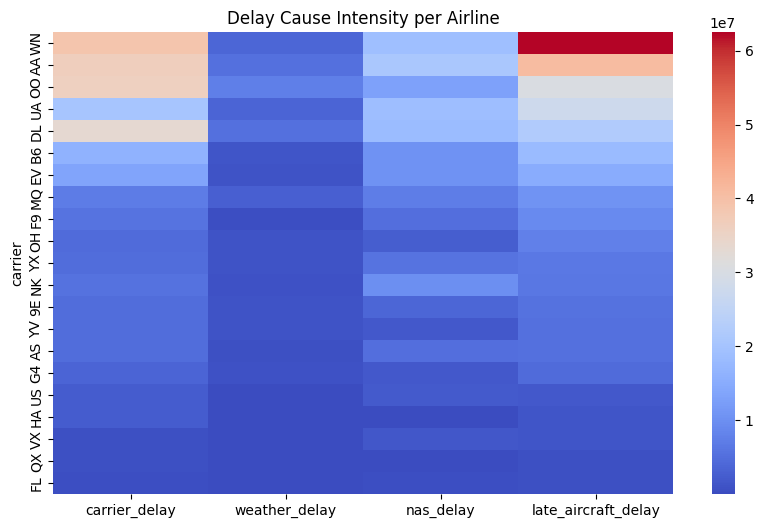

In [52]:
plt.figure(figsize=(10,6))
sns.heatmap(result_2.set_index('carrier'), cmap='coolwarm')
plt.title('Delay Cause Intensity per Airline')
plt.savefig('rootcause.png')
plt.show()

This visualization uses a heatmap to display the intensity of different delay types across airlines. This approach allows for quick pattern recognition without the need to interpret raw numbers. Darker colors represent higher delay contributions, making it easier to identify dominant issues.

The heatmap reveals that most airlines exhibit high intensity in the late aircraft delay category, indicating that operational delays are the primary driver. This pattern is consistent across multiple airlines, suggesting a systemic issue rather than isolated cases. This insight highlights the need for broader operational improvements rather than focusing on individual airlines alone

####Opertional Issue Indicator - Query 3

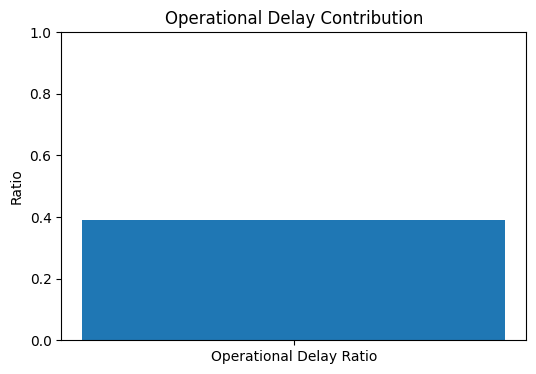

In [53]:
ratio = result_3['operational_ratio'][0]
plt.figure(figsize=(6,4))
plt.bar(['Operational Delay Ratio'], [ratio])
plt.ylim(0,1)
plt.title('Operational Delay Contribution')
plt.ylabel('Ratio')
plt.savefig('operational.png')
plt.show()

This visualization presents the proportion of operational delays relative to total delays using a simple chart. Its purpose is to clearly illustrate how much internal factors contribute to overall delays.

With a value of approximately 38.6%, it is evident that a substantial portion of delays originates from operational factors, particularly late aircraft delays. While not an absolute majority, this proportion is significant enough to indicate that internal inefficiencies play a major role in the overall delay system. This insight reinforces previous findings that improving operational efficiency could have a meaningful impact on reducing delays

##Insight

Based on the overall analysis, flight delays are not evenly distributed but are concentrated among several underperforming airlines. Carriers such as WN and AA exhibit both high average delays and significant cancellation rates, classifying them as high-risk airlines that can negatively impact customer experience.

From a root cause perspective, delays are primarily driven by operational factors, particularly late aircraft delays, which consistently appear as the dominant contributor across most airlines. This is further supported by the calculated ratio indicating that approximately 38.6% of total delays are operational, suggesting inefficiencies in scheduling and aircraft turnaround processes.

Additionally, the heatmap reveals that delay patterns are not isolated to specific airlines but are systemic across the industry. This indicates that the core issue is less about external factors such as weather and more about suboptimal operational efficiency.

Overall, these insights highlight that improving operational processes represents the most impactful opportunity to reduce delays and enhance service quality

##Recommendations

Based on the insights, several strategic recommendations can be implemented by the online travel platform to improve user experience and service quality.

First, the platform should introduce a performance-based ranking system, prioritizing airlines with lower delay and cancellation rates in search results. This helps guide users toward more reliable flight options.

Second, enhancing delay transparency is crucial. Displaying estimated delay risks or historical performance metrics during the booking process allows users to make more informed decisions.

Third, the platform can implement a risk flagging system, highlighting airlines with poor performance (high delays and cancellations), enabling users to better assess potential risks before booking.

Fourth, given the strong influence of operational factors, the platform may consider collaborating with airlines to encourage operational improvements, such as better scheduling and reducing cascading delays.

By implementing these strategies, the platform can not only improve customer satisfaction but also strengthen its positioning as a data-driven and user-centric service